In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy.stats import ttest_ind, f_oneway, chi2_contingency

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/interim/cleaned_day2.csv")

df.head()

,SKU_ID,Category,ABC_Class,Supplier_Name,Warehouse_Location,Received_Date,Last_Purchase_Date,Stock_Age_Days,Quantity_On_Hand,Damaged_Qty,Returns_Qty,Avg_Daily_Sales,Forecast_Next_30d,Reorder_Point,Safety_Stock,Lead_Time_Days,Total_Inventory_Value_USD,Supplier_OnTime_Pct,Inventory_Status
0,SKU_14996,Household,A,NextGen Traders,Chennai Warehouse,2024-06-11 00:00:00,2024-07-11,212,482.0,13,9,19.84,459.32,126,47,7.0,45555.63,82.64,Normal
1,SKU_10247,Snacks,C,NextGen Traders,Bangalore Warehouse,2024-11-24 00:00:00,2025-03-19,357,640.0,8,6,34.81,1072.54,110,75,5.0,36577.48,94.58,Normal
2,SKU_16215,Dairy,C,NextGen Traders,Chennai Warehouse,2023-02-01 00:00:00,2023-03-06,104,538.0,5,3,49.66,1891.81,118,66,12.0,23742.67,98.22,Overstock
3,SKU_13545,Bakery,A,Prime Distribution,Chennai Warehouse,2024-03-13 00:00:00,2024-06-04,161,530.0,9,2,20.00,662.42,119,11,8.0,49287.57,97.45,Low Stock
4,SKU_15397,Produce,B,Global Retail Supply,Chennai Warehouse,2023-05-01 00:00:00,2023-05-09,289,397.0,14,3,32.63,1115.41,128,42,3.0,16929.86,86.75,Overstock


In [7]:
df.groupby("Category")["Avg_Daily_Sales"].mean().sort_values(ascending=False)

Category
Snacks           35.283084
Personal Care    35.214116
Household        35.145966
Produce          34.808285
Dairy            34.756040
Beverages        34.750796
Frozen Foods     34.649361
Bakery           34.469190
Name: Avg_Daily_Sales, dtype: float64

In [17]:
df["Inventory_Risk"] = np.where(
    df["Inventory_Status"].isin(["Critical", "Low Stock"]),
    "High Risk",
    "Low Risk"
)

In [18]:
df["Inventory_Risk"].value_counts()

Inventory_Risk
Low Risk     3392
High Risk    3308
Name: count, dtype: int64

In [22]:
from scipy.stats import ttest_ind

high_risk = df[df["Inventory_Risk"] == "High Risk"]["Avg_Daily_Sales"]
low_risk = df[df["Inventory_Risk"] == "Low Risk"]["Avg_Daily_Sales"]

t_stat, p_value = ttest_ind(high_risk, low_risk)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.095173515113798
P-value: 0.27348000485119245


In [23]:
df.groupby("Category")["Stock_Age_Days"].mean().sort_values(ascending=False)

Category
Beverages        211.691194
Produce          207.273878
Bakery           205.350665
Personal Care    204.715496
Dairy            203.376932
Snacks           200.831776
Frozen Foods     197.363088
Household        196.780073
Name: Stock_Age_Days, dtype: float64

In [24]:
groups = [
    group["Stock_Age_Days"]
    for _, group in df.groupby("Category")
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 1.6074561410589585
P-value: 0.12820434054077723


In [25]:
contingency = pd.crosstab(
    df["ABC_Class"],
    df["Inventory_Status"]
)

contingency

Inventory_Status,Critical,Low Stock,Normal,Overstock
ABC_Class,,,,
A,563,563,606,558
B,547,540,586,564
C,550,545,566,512


In [26]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(contingency)

print("Chi-Square:", chi2)
print("P-value:", p_value)

Chi-Square: 2.0836442991460222
P-value: 0.9118472496945949


In [27]:
df["Days_Of_Inventory"] = (
    df["Quantity_On_Hand"] /
    df["Avg_Daily_Sales"]
)

In [28]:
df["Days_Of_Inventory"].describe()

count    6700.000000
mean       13.723371
std        14.184381
min         0.182949
25%         9.119526
50%        12.011655
75%        15.795997
max       669.000000
Name: Days_Of_Inventory, dtype: float64

In [29]:
df["Damage_Rate"] = (
    df["Damaged_Qty"] /
    df["Quantity_On_Hand"]
) * 100

In [30]:
df["Damage_Rate"].describe()

count    6700.000000
mean        2.654349
std         5.643101
min         0.000000
25%         1.430275
50%         2.247191
75%         3.283289
max       400.000000
Name: Damage_Rate, dtype: float64

In [31]:
df["Return_Rate"] = (
    df["Returns_Qty"] /
    df["Avg_Daily_Sales"]
) * 100

In [32]:
df["Return_Rate"].describe()

count    6700.000000
mean       24.535665
std        24.564206
min         0.000000
25%        13.337189
50%        21.595357
75%        31.218959
max      1000.000000
Name: Return_Rate, dtype: float64

In [33]:
df["Supply_Risk_Score"] = (
    df["Lead_Time_Days"] *
    (100 - df["Supplier_OnTime_Pct"])
)

In [34]:
df["Supply_Risk_Score"].describe()

count    6700.000000
mean       90.111287
std        55.226292
min         2.390000
25%        44.877500
50%        82.850000
75%       126.315000
max       335.920000
Name: Supply_Risk_Score, dtype: float64

In [35]:
df["Purchase_Year"] = (
    pd.to_datetime(df["Last_Purchase_Date"]).dt.year
)

df["Purchase_Month"] = (
    pd.to_datetime(df["Last_Purchase_Date"]).dt.month_name()
)

df["Purchase_Day"] = (
    pd.to_datetime(df["Last_Purchase_Date"]).dt.day
)

In [36]:
df["Purchase_Year"].value_counts().sort_index()

Purchase_Year
2023    2416
2024    2828
2025    1456
Name: count, dtype: int64

In [37]:
df.groupby("Purchase_Year")["Total_Inventory_Value_USD"].mean()

Purchase_Year
2023    29277.290211
2024    29115.842777
2025    28118.579408
Name: Total_Inventory_Value_USD, dtype: float64

In [38]:
df.groupby("Purchase_Year")["Avg_Daily_Sales"].mean()

Purchase_Year
2023    34.863576
2024    34.828299
2025    35.031909
Name: Avg_Daily_Sales, dtype: float64

In [39]:
df["Purchase_Month"].value_counts()

Purchase_Month
May          724
April        676
June         640
March        636
July         582
January      544
February     531
August       499
December     494
November     472
October      452
September    450
Name: count, dtype: int64

In [40]:
df.groupby("Purchase_Month")["Avg_Daily_Sales"].mean()

Purchase_Month
April        34.376080
August       34.954890
December     34.581316
February     35.584463
January      34.704007
July         34.011134
June         34.266937
March        34.859953
May          35.249061
November     35.677691
October      34.935553
September    35.879467
Name: Avg_Daily_Sales, dtype: float64

In [41]:
df.groupby("Purchase_Month")[
    "Total_Inventory_Value_USD"
].mean().sort_values(ascending=False)

Purchase_Month
December     29865.416012
September    29610.217667
October      29537.069624
April        29279.333105
February     29260.830523
August       29244.918194
June         29104.261576
November     29048.193896
March        28553.098001
May          28418.518798
July         28062.278744
January      28046.462776
Name: Total_Inventory_Value_USD, dtype: float64

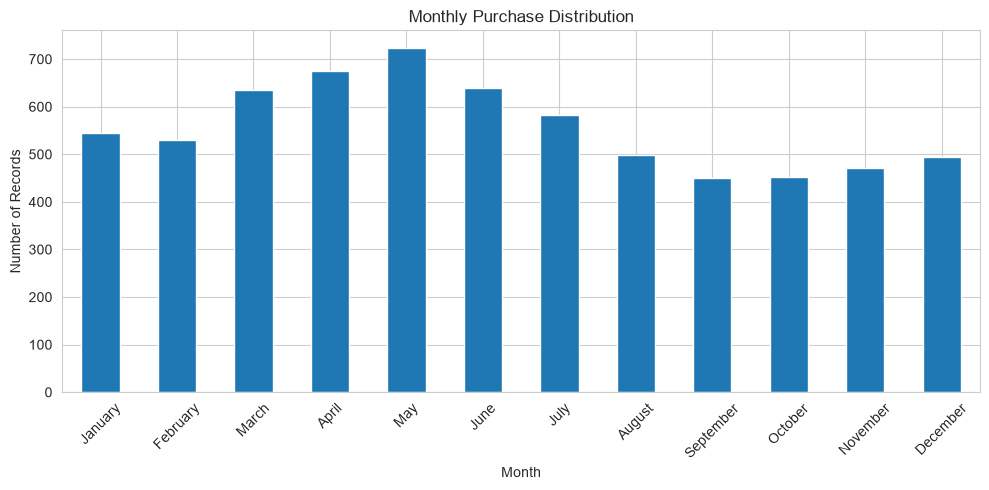

In [42]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_counts = (
    df["Purchase_Month"]
    .value_counts()
    .reindex(month_order)
)

plt.figure(figsize=(10,5))
monthly_counts.plot(kind="bar")

plt.title("Monthly Purchase Distribution")
plt.xlabel("Month")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../reports/figures/monthly_purchase_distribution.png")
plt.show()

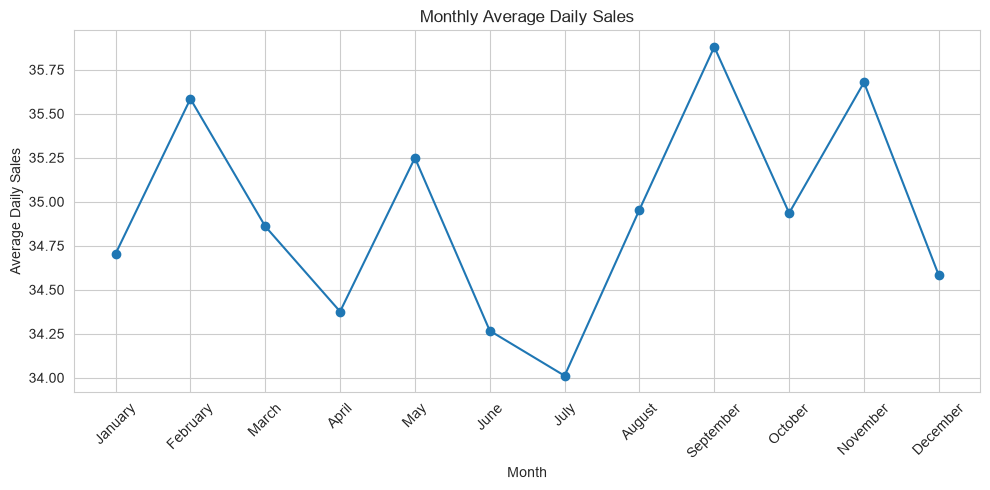

In [43]:
monthly_sales = (
    df.groupby("Purchase_Month")["Avg_Daily_Sales"]
      .mean()
      .reindex(month_order)
)

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker="o")

plt.title("Monthly Average Daily Sales")
plt.xlabel("Month")
plt.ylabel("Average Daily Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../reports/figures/monthly_avg_sales.png")
plt.show()

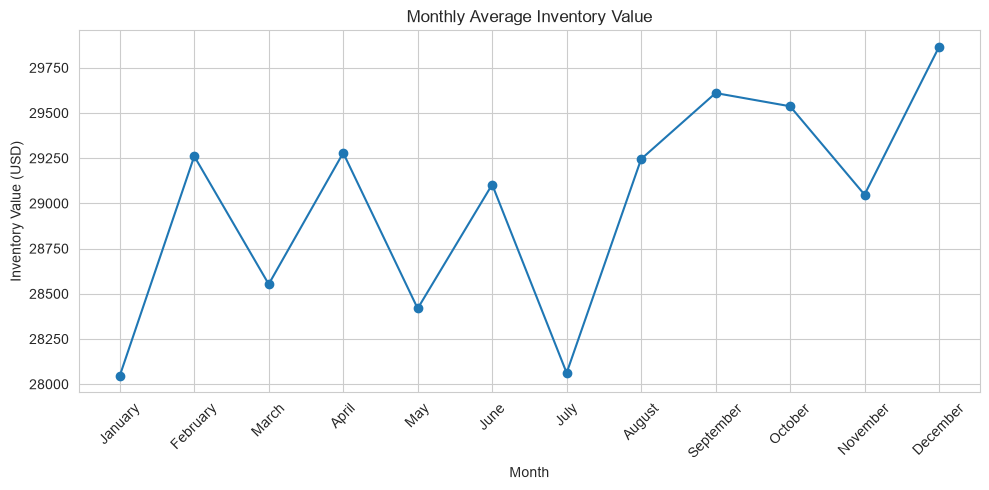

In [44]:
monthly_value = (
    df.groupby("Purchase_Month")["Total_Inventory_Value_USD"]
      .mean()
      .reindex(month_order)
)

plt.figure(figsize=(10,5))
plt.plot(monthly_value.index,
         monthly_value.values,
         marker="o")

plt.title("Monthly Average Inventory Value")
plt.xlabel("Month")
plt.ylabel("Inventory Value (USD)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../reports/figures/monthly_inventory_value.png")
plt.show()